### Import statements

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.formula.api import ols
import pandas as pd
from datetime import datetime
import seaborn as sns

## Sensor calibration

### Subcritical sensor calibration curve

b0 = 36.867167582476284
b1 = 2.2729171352478246


Text(0, 0.5, 'Water level (cm)')

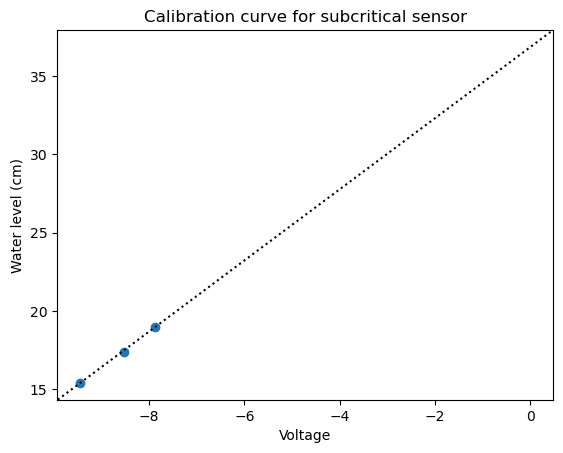

In [96]:
# calibration data
sub_voltage = np.array([-9.4592, -8.5297, -7.8816])
sub_height = np.array([15.4, 17.4, 19])                     # cm
sub_df = pd.DataFrame({'Voltage':sub_voltage, 'Height':sub_height})

# linear fit
sub_calibration = ols('Height ~ Voltage', data=sub_df).fit()
sub_b0, sub_b1 = sub_calibration.params
print(f'b0 = {sub_b0}')
print(f'b1 = {sub_b1}')

# plot
plt.scatter(sub_voltage, sub_height)
plt.axline(xy1=(0,sub_b0), slope=sub_b1, color='black', linestyle=':')
plt.title('Calibration curve for subcritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Supercritical sensor calibration curve

b0 = 28.6137223023922
b1 = 2.2998132138163467


Text(0, 0.5, 'Water level (cm)')

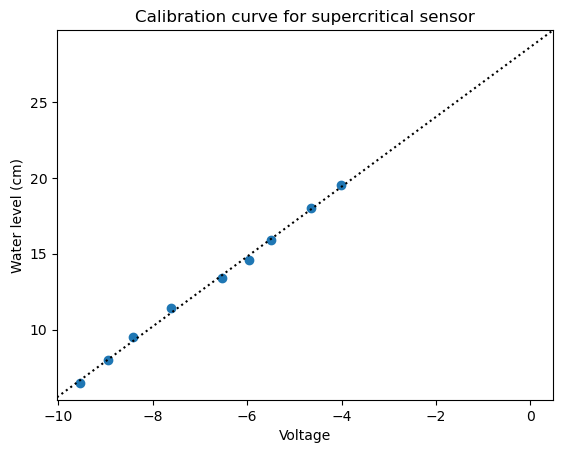

In [97]:
# calibration data
super_voltage = np.array([-9.5491, -8.9420, -8.4136, -7.6184, -6.5391, -5.9702, -5.4983, -4.6409, -4.0175])
super_height = np.array([6.5, 8, 9.5, 11.4, 13.4, 14.6, 15.9, 18, 19.5])    # cm
super_df = pd.DataFrame({'Voltage':super_voltage, 'Height':super_height})

# linear fit
super_calibration = ols('Height ~ Voltage', data=super_df).fit()
super_b0, super_b1 = super_calibration.params
print(f'b0 = {super_b0}')
print(f'b1 = {super_b1}')

# plot
plt.scatter(super_voltage, super_height)
plt.axline(xy1=(0,super_b0), slope=super_b1, color='black', linestyle=':')
plt.title('Calibration curve for supercritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Head tank sensor calibration curve

b0 = 50.484996799317166
b1 = 2.0198975781500037


Text(0, 0.5, 'Water level (cm)')

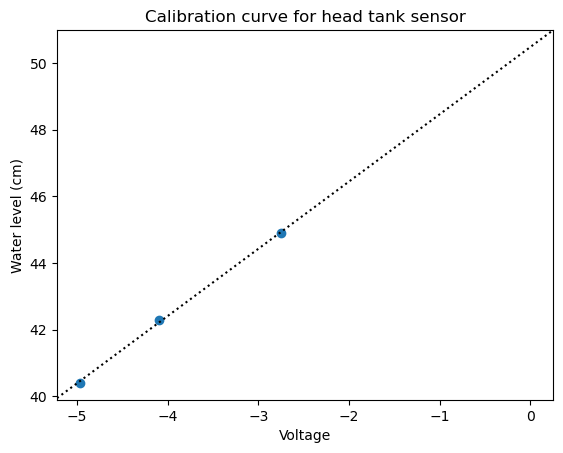

In [98]:
# calibration data
head_voltage = np.array([-2.75, -4.09, -4.97])
head_distance = np.array([9.6, 12.2, 14.1])    # cm, sensor distance from water surface
head_df = pd.DataFrame({'Voltage':head_voltage, 'Distance':head_distance})

# convert distance from water surface to water level
dist_bottom_to_vernier = 143.4 # cm
vernier_reading = 0 # ADD VERNIER READING TO WHATEVER OLS SPITS OUT FOR AN ACCURATE INTERCEPT
#vernier_reading = 0.452*30.48 # ft to cm THIS WILL BE MODIFIED THROUGHOUT EXPERIMENT SO WATCH THIS WHEN PROCESSING DATA
length_vernier = 88.9 # cm

head_df['Height'] = dist_bottom_to_vernier - (length_vernier - vernier_reading) - head_df['Distance']

# linear fit
head_calibration = ols('Height ~ Voltage', data=head_df).fit()
head_b0, head_b1 = head_calibration.params
print(f'b0 = {head_b0}')
print(f'b1 = {head_b1}')

# plot
plt.scatter(head_df['Voltage'], head_df['Height'])
plt.axline(xy1=(0,head_b0), slope=head_b1, color='black', linestyle=':')
plt.title('Calibration curve for head tank sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

#### CALCULATIONS DURING EXPERIMENT

In [99]:
sub_calib_voltage = -5.0048
head_calib_voltage = -9.2691
calib_vernier = 0.262

# EDIT THESE
voltage_subcritical = -3.8045
voltage_head = -3.4036
trial_vernier = 0.505

height_subcritical = 15.88 + sub_b1 * (voltage_subcritical - sub_calib_voltage)
height_head = 15.88 + head_b1 * (voltage_head - head_calib_voltage) + 30.48 * (trial_vernier - calib_vernier)

head_diff = height_head - height_subcritical
print(f'Subcritical height is {height_subcritical:0.2f} cm')
print(f'Head tank height is {height_head:0.2f} cm')
print(f'Head difference is {head_diff:0.2f} cm')

Subcritical height is 18.61 cm
Head tank height is 35.13 cm
Head difference is 16.53 cm


## Load data

### Read venturi meter csv file

In [100]:
# load both dfs and stack them
venturi_file = '11-24-2025.csv'
venturi_df = pd.read_csv(venturi_file, sep=';')
venturi_df = venturi_df.drop(['State PV', 'State SV', 'State TV', 'QV', 'State QV', 'Current [mA] ', 'State Current'], axis=1)
venturi_df['PV [in H2O] '] = venturi_df['PV [in H2O] '].str.replace(',', '.')
venturi_df['SV [C] '] = venturi_df['SV [C] '].str.replace(',', '.')
venturi_df['TV'] = venturi_df['TV'].str.replace(',', '.')
venturi_df['Time stamp'] = pd.to_datetime(venturi_df['Time stamp'], format='%d.%m.%Y %H:%M:%S')

venturi_2 = '11-24-2025-a.csv'
venturi_df2 = pd.read_csv(venturi_2, sep=';')
venturi_df2 = venturi_df2.drop(['State PV', 'State SV', 'State TV', 'QV', 'State QV', 'Current [mA] ', 'State Current'], axis=1)
venturi_df2['PV [in H2O] '] = venturi_df2['PV [in H2O] '].str.replace(',', '.')
venturi_df2['SV [C] '] = venturi_df2['SV [C] '].str.replace(',', '.')
venturi_df2['TV'] = venturi_df2['TV'].str.replace(',', '.')
venturi_df2['Time stamp'] = pd.to_datetime(venturi_df2['Time stamp'], format='%d.%m.%Y %H:%M:%S')

# stack dfs
stacked_venturis = pd.concat([venturi_df, venturi_df2], ignore_index=True)

display(stacked_venturis)

,Time stamp,PV [in H2O],SV [C],TV
0,2025-11-24 09:34:19,0.106309719383717,20.9362182617188,0.000425238948082551
1,2025-11-24 09:34:21,0.106515794992447,20.9363708496094,0.000426063197664917
2,2025-11-24 09:34:24,0.105973467230797,20.9363708496094,0.000423893943661824
3,2025-11-24 09:34:26,0.106225244700909,20.9363708496094,0.000424901052610949
4,2025-11-24 09:34:29,0.106799252331257,20.9363708496094,0.000427197082899511
...,...,...,...,...
3451,2025-11-24 17:40:05,23.2496490478516,21.1701049804688,0.0929986014962196
3452,2025-11-24 17:40:08,22.9070987701416,21.1702880859375,0.0916283950209618
3453,2025-11-24 17:40:10,23.6384925842285,21.1702880859375,0.0945539921522141
3454,2025-11-24 17:40:13,23.1700553894043,21.1704711914063,0.0926802381873131


### Read ADV data file

In [101]:
from datetime import datetime, timedelta

adv_file = 'hre_adv20251124110727.dat'
adv_data = pd.read_csv(adv_file, sep='\s+', header=None)
start_time = datetime(2025, 11, 24, 11, 7, 27)
end_time = datetime(2025, 11, 24, 11, 10, 59)

freq = 15 # Hz
step = timedelta(seconds=(1/freq))

velocity = adv_data[3]
datetimes = np.arange(start_time, end_time, step).astype(datetime)

adv_data = pd.DataFrame({'datetimes':datetimes,'velocity (m/s)':velocity[:len(datetimes)]})

display(adv_data)

,datetimes,velocity (m/s)
0,2025-11-24 11:07:27.000000,0.2598
1,2025-11-24 11:07:27.066667,0.2613
2,2025-11-24 11:07:27.133334,0.2631
3,2025-11-24 11:07:27.200001,0.2611
4,2025-11-24 11:07:27.266668,0.2822
...,...,...
3175,2025-11-24 11:10:58.667725,0.2610
3176,2025-11-24 11:10:58.734392,0.2752
3177,2025-11-24 11:10:58.801059,0.2869
3178,2025-11-24 11:10:58.867726,0.2920


In [102]:
adv_file1 = 'hre_adv20251124165829.dat'
adv_data1 = pd.read_csv(adv_file1, sep='\s+', header=None)
start_time1 = datetime(2025, 11, 24, 16, 58, 29)
end_time1 = datetime(2025, 11, 24, 17, 36, 5)

freq = 15 # Hz
step = timedelta(seconds=(1/freq))

velocity = adv_data1[3]
datetimes = np.arange(start_time1, end_time1, step).astype(datetime)

adv_data1 = pd.DataFrame({'datetimes':datetimes[:len(velocity)],'velocity (m/s)':velocity})

display(adv_data1)

,datetimes,velocity (m/s)
0,2025-11-24 16:58:29.000000,0.4937
1,2025-11-24 16:58:29.066667,0.4459
2,2025-11-24 16:58:29.133334,0.4172
3,2025-11-24 16:58:29.200001,0.4362
4,2025-11-24 16:58:29.266668,0.4565
...,...,...
33830,2025-11-24 17:36:04.344610,0.6165
33831,2025-11-24 17:36:04.411277,0.5500
33832,2025-11-24 17:36:04.477944,0.5258
33833,2025-11-24 17:36:04.544611,0.5137


In [103]:
adv_file2 = 'hre_adv20251124173721.dat'
adv_data2 = pd.read_csv(adv_file2, sep='\s+', header=None)
start_time2 = datetime(2025, 11, 24, 17, 37, 21)
end_time2 = datetime(2025, 11, 24, 17, 54, 9)

freq = 20 # Hz
step = timedelta(seconds=(1/freq))

velocity = adv_data2[3]
datetimes = np.arange(start_time2, end_time2, step).astype(datetime)

adv_data2 = pd.DataFrame({'datetimes':datetimes,'velocity (m/s)':velocity[:len(datetimes)]})

display(adv_data2)

,datetimes,velocity (m/s)
0,2025-11-24 17:37:21.000,0.652
1,2025-11-24 17:37:21.050,0.598
2,2025-11-24 17:37:21.100,0.553
3,2025-11-24 17:37:21.150,0.530
4,2025-11-24 17:37:21.200,0.619
...,...,...
20155,2025-11-24 17:54:08.750,0.000
20156,2025-11-24 17:54:08.800,2.690
20157,2025-11-24 17:54:08.850,1.872
20158,2025-11-24 17:54:08.900,1.836


In [104]:
stacked_advdata = pd.concat([adv_data, adv_data1, adv_data2], ignore_index=True)
display(stacked_advdata)

,datetimes,velocity (m/s)
0,2025-11-24 11:07:27.000000,0.2598
1,2025-11-24 11:07:27.066667,0.2613
2,2025-11-24 11:07:27.133334,0.2631
3,2025-11-24 11:07:27.200001,0.2611
4,2025-11-24 11:07:27.266668,0.2822
...,...,...
57170,2025-11-24 17:54:08.750000,0.0000
57171,2025-11-24 17:54:08.800000,2.6900
57172,2025-11-24 17:54:08.850000,1.8720
57173,2025-11-24 17:54:08.900000,1.8360


### Read height sensor csv files

In [105]:
import glob

csv_files = sorted(glob.glob('*sensor_data.csv'))
dfs = []

for file_name in csv_files:
    try:
        df = pd.read_csv(file_name)
        dfs.append(df)
        print(f"Successfully read: {file_name}")
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

V_ai0 = np.empty(len(csv_files))
V_ai1 = np.empty(len(csv_files))
V_ai2 = np.empty(len(csv_files))

for i, df in enumerate(dfs):
    V_ai0[i] = df['V_ai0'].mean()
    V_ai1[i] = df['V_ai1'].mean()
    V_ai2[i] = df['V_ai2'].mean()

sensor_data = pd.DataFrame({'V_ai0': V_ai0, 'V_ai1': V_ai1, 'V_ai2': V_ai2}) # note that trial indices are one less than the ones I wrote in the notebook
sensor_data['Vernier'] = 0.505
sensor_data['Filenames'] = csv_files

Successfully read: 2025-11-24_11-08-18_sensor_data.csv
Successfully read: 2025-11-24_16-51-13_sensor_data.csv
Successfully read: 2025-11-24_16-54-19_sensor_data.csv
Successfully read: 2025-11-24_16-56-27_sensor_data.csv
Successfully read: 2025-11-24_16-59-13_sensor_data.csv
Successfully read: 2025-11-24_17-04-35_sensor_data.csv
Successfully read: 2025-11-24_17-08-12_sensor_data.csv
Successfully read: 2025-11-24_17-10-25_sensor_data.csv
Successfully read: 2025-11-24_17-12-13_sensor_data.csv
Successfully read: 2025-11-24_17-14-19_sensor_data.csv
Successfully read: 2025-11-24_17-16-14_sensor_data.csv
Successfully read: 2025-11-24_17-18-15_sensor_data.csv
Successfully read: 2025-11-24_17-21-26_sensor_data.csv
Successfully read: 2025-11-24_17-26-36_sensor_data.csv
Successfully read: 2025-11-24_17-32-35_sensor_data.csv
Successfully read: 2025-11-24_17-34-40_sensor_data.csv
Successfully read: 2025-11-24_17-38-09_sensor_data.csv


### Convert voltages to water heights

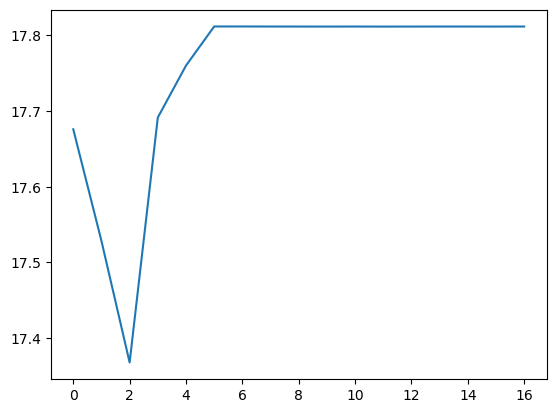

In [106]:
sensor_data['Supercritical Height (cm)'] = 15.88 + super_b1 * (sensor_data['V_ai1'] + 0.9352) 

plt.plot(sensor_data['Supercritical Height (cm)'])

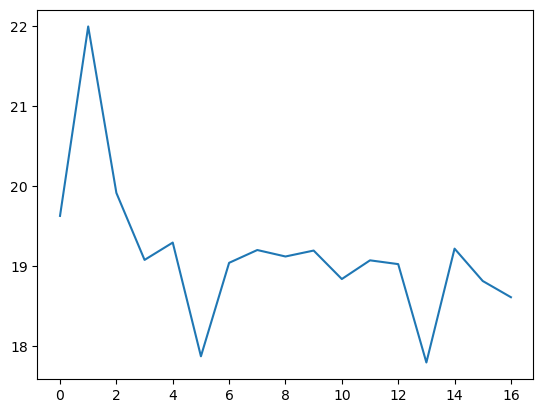

In [107]:
sensor_data['Subcritical Height (cm)'] = 15.88 + sub_b1 * (sensor_data['V_ai0'] - sub_calib_voltage)

plt.plot(sensor_data['Subcritical Height (cm)'])

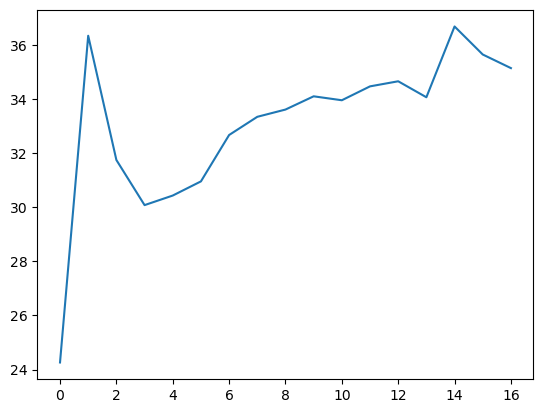

In [108]:
sensor_data['Head Tank Height (cm)'] = 15.88 + 30.48*(sensor_data['Vernier'] - calib_vernier) + head_b1 * (sensor_data['V_ai2'] - head_calib_voltage)

plt.plot(sensor_data['Head Tank Height (cm)'])

### Plot the curves together

Text(0, 0.5, 'Water level (cm)')

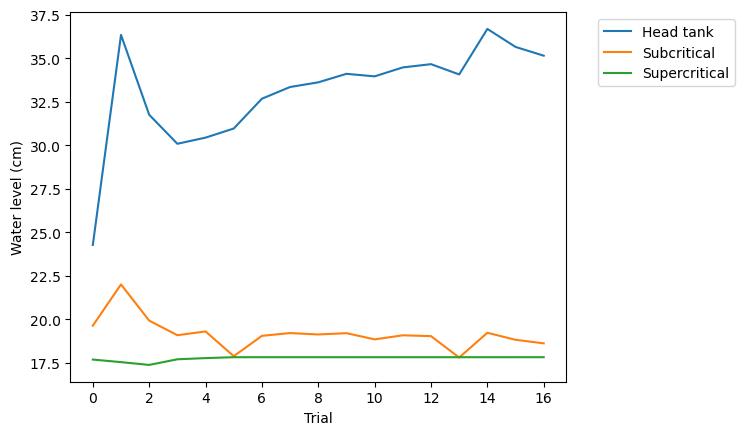

In [109]:
plt.plot(sensor_data['Head Tank Height (cm)'])
plt.plot(sensor_data['Subcritical Height (cm)'])
plt.plot(sensor_data['Supercritical Height (cm)'])


plt.legend(['Head tank', 'Subcritical', 'Supercritical'], bbox_to_anchor=(1.05, 1))
plt.xlabel('Trial')
plt.ylabel('Water level (cm)')

## Stage discharge curve

### Calculate discharge

In [110]:
# Process PV values from venturi meter to match sensor_data trials
from datetime import timedelta

# First, parse the venturi data timestamps
stacked_venturis['datetime'] = pd.to_datetime(stacked_venturis['Time stamp'], format='%d.%m.%Y %H:%M:%S')

# Replace comma with period for PV values (European decimal format)
stacked_venturis['PV [in H2O] '] = stacked_venturis['PV [in H2O] '].astype(str).str.replace(',', '.').astype(float)

# Extract timestamps from sensor_data file names and calculate average PV for each trial
pv_averages = []
adv_averages = []

for i, file_name in enumerate(csv_files):
    # Extract timestamp from filename (format: YYYY-MM-DD_HH-MM-SS_sensor_data.csv)
    # The timestamp is the end time of the trial
    timestamp_str = file_name.split('_sensor_data.csv')[0]
    end_time = pd.to_datetime(timestamp_str, format='%Y-%m-%d_%H-%M-%S')
    start_time = end_time - timedelta(seconds=30)
    
    # Filter venturi data for this time window
    venturi_subset = stacked_venturis[(stacked_venturis['datetime'] >= start_time) & (stacked_venturis['datetime'] <= end_time)]
    adv_subset = stacked_advdata[(stacked_advdata['datetimes'] >= start_time) & (stacked_advdata['datetimes'] <= end_time)]
    
    # Calculate average PV
    if len(venturi_subset) > 0:
        avg_pv = venturi_subset['PV [in H2O] '].mean()
    else:
        avg_pv = np.nan  # No data in this time window
    
    # calculate avg velocity
    if len(adv_subset) > 0:
        avg_velocity = adv_subset['velocity (m/s)'].mean()
    else:
        avg_velocity = np.nan
    
    pv_averages.append(avg_pv)
    adv_averages.append(avg_velocity)

    print(f"Trial {i}: {file_name}")
    print(f"  Time window: {start_time} to {end_time}")
    print(f"  Average PV: {avg_pv:.6f} in H2O")
    print(f' Average velocity: {avg_velocity:0.3f} m/s')
    print()

# Add average PV values to sensor_data dataframe
sensor_data['Average PV (in H2O)'] = pv_averages
sensor_data['Average velocity (m/s)'] = adv_averages
sensor_data = sensor_data.dropna()

Trial 0: 2025-11-24_11-08-18_sensor_data.csv
  Time window: 2025-11-24 11:07:48 to 2025-11-24 11:08:18
  Average PV: 5.730495 in H2O
 Average velocity: 0.269 m/s

Trial 1: 2025-11-24_16-51-13_sensor_data.csv
  Time window: 2025-11-24 16:50:43 to 2025-11-24 16:51:13
  Average PV: 16.385773 in H2O
 Average velocity: nan m/s

Trial 2: 2025-11-24_16-54-19_sensor_data.csv
  Time window: 2025-11-24 16:53:49 to 2025-11-24 16:54:19
  Average PV: 14.159082 in H2O
 Average velocity: nan m/s

Trial 3: 2025-11-24_16-56-27_sensor_data.csv
  Time window: 2025-11-24 16:55:57 to 2025-11-24 16:56:27
  Average PV: 13.650050 in H2O
 Average velocity: nan m/s

Trial 4: 2025-11-24_16-59-13_sensor_data.csv
  Time window: 2025-11-24 16:58:43 to 2025-11-24 16:59:13
  Average PV: 13.578475 in H2O
 Average velocity: 0.437 m/s

Trial 5: 2025-11-24_17-04-35_sensor_data.csv
  Time window: 2025-11-24 17:04:05 to 2025-11-24 17:04:35
  Average PV: 16.993327 in H2O
 Average velocity: 0.525 m/s

Trial 6: 2025-11-24_17-

### Relationship between PV and discharge for flume

In [111]:
sensor_data['Discharge (m^3/s)'] = 0.08218*((sensor_data['Average PV (in H2O)'] - 0.11)/42.39)**(1/2)

### ADV vs venturi meter

Text(0.5, 1.0, 'Comparison between ADV and Venturimeter-derived velocities')

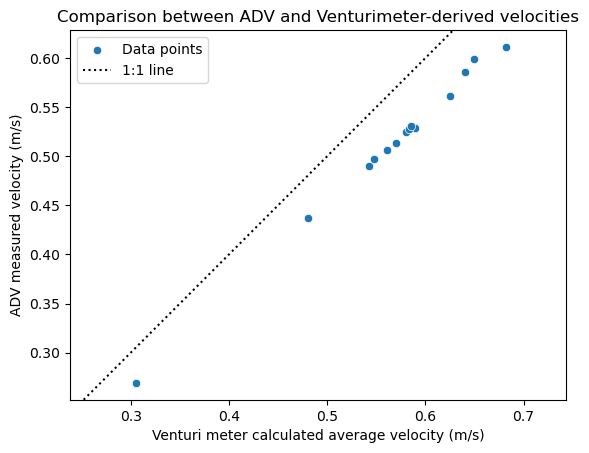

In [112]:
sensor_data['Venturi velocity (m/s)'] = sensor_data['Discharge (m^3/s)'] / (0.5 * (sensor_data['Subcritical Height (cm)']/100))

sns.scatterplot(x='Venturi velocity (m/s)', y='Average velocity (m/s)', data=sensor_data)
plt.axline(xy1=(0.3,0.3), slope=1, color='black', linestyle=':')
plt.axis('equal')
plt.xlabel('Venturi meter calculated average velocity (m/s)')
plt.ylabel('ADV measured velocity (m/s)')
plt.legend(['Data points', '1:1 line'])
plt.title('Comparison between ADV and Venturimeter-derived velocities')

### Calculate head difference

In [113]:
sensor_data['Head diff (cm)'] = sensor_data['Head Tank Height (cm)'] - sensor_data['Subcritical Height (cm)']
sensor_data = sensor_data.drop([5, 13])

display(sensor_data)

,V_ai0,V_ai1,V_ai2,Vernier,Filenames,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Average PV (in H2O),Average velocity (m/s),Discharge (m^3/s),Venturi velocity (m/s),Head diff (cm)
0,-3.357145,-0.154343,-8.786971,0.505,2025-11-24_11-08-18_sensor_data.csv,17.675825,19.624984,24.260490,5.730495,0.269195,0.029924,0.304960,4.635507
4,-3.503855,-0.117778,-5.733980,0.505,2025-11-24_16-59-13_sensor_data.csv,17.759917,19.291523,30.427221,13.578475,0.437117,0.046323,0.480239,11.135698
6,-3.615268,-0.095309,-4.626886,0.505,2025-11-24_17-08-12_sensor_data.csv,17.811592,19.038291,32.663438,16.866686,0.490445,0.051669,0.542788,13.625147
7,-3.544834,-0.095334,-4.294079,0.505,2025-11-24_17-10-25_sensor_data.csv,17.811535,19.198383,33.335673,17.466792,0.496938,0.052586,0.547816,14.137290
8,-3.580417,-0.095351,-4.161254,0.505,2025-11-24_17-12-13_sensor_data.csv,17.811495,19.117503,33.603966,18.178795,0.506811,0.053654,0.561304,14.486463
9,-3.547795,-0.095361,-3.919169,0.505,2025-11-24_17-14-19_sensor_data.csv,17.811472,19.191652,34.092952,18.904731,0.513794,0.054721,0.570256,14.901299
10,-3.704402,-0.095346,-3.991237,0.505,2025-11-24_17-16-14_sensor_data.csv,17.811507,18.835698,33.947383,19.456557,0.529080,0.055518,0.589501,15.111686
11,-3.601577,-0.095373,-3.737209,0.505,2025-11-24_17-18-15_sensor_data.csv,17.811446,19.069410,34.460493,19.526659,0.527341,0.055619,0.583330,15.391083
12,-3.622394,-0.095357,-3.644243,0.505,2025-11-24_17-21-26_sensor_data.csv,17.811482,19.022094,34.648275,19.590660,0.530733,0.055710,0.585744,15.626180
14,-3.537220,-0.095348,-2.641987,0.505,2025-11-24_17-32-35_sensor_data.csv,17.811503,19.215687,36.672730,22.720629,0.561354,0.060019,0.624690,17.457043


### Graph stage vs discharge 

Text(0.5, 1.0, 'Stage discharge curve')

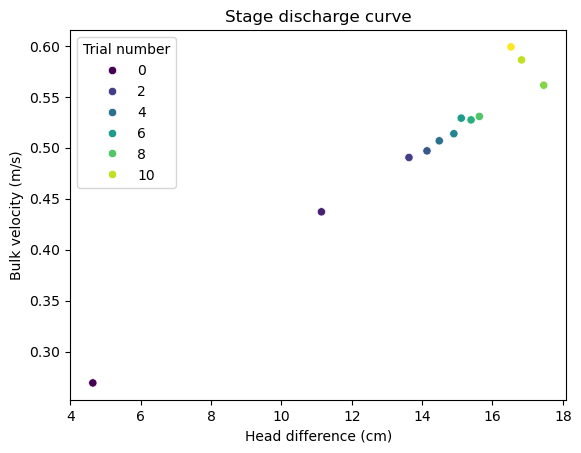

In [114]:
sns.scatterplot(x='Head diff (cm)', y='Average velocity (m/s)', hue=np.arange(0, len(sensor_data)), data=sensor_data, palette='viridis')

# for i in range(len(sensor_data)):
#     plt.text(sensor_data['Head diff (cm)'][i], sensor_data['Discharge (m^3/s)'][i], i)
#plt.plot(sensor_data['Head diff (cm)'], sensor_data['Discharge (m^3/s)'], color='black', linestyle=':')
#sns.lineplot(x='Head diff (cm)', y='Delta P', data=sensor_data)
plt.xlabel('Head difference (cm)')
plt.ylabel('Bulk velocity (m/s)')
plt.legend(title='Trial number')
plt.title('Stage discharge curve')

Text(0.5, 1.0, 'Stage velocity curve')

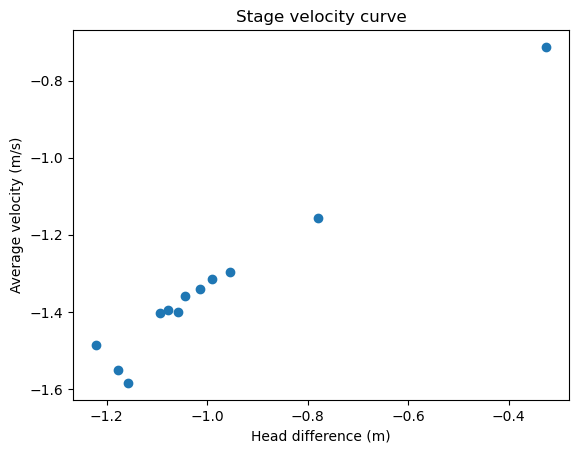

In [115]:
# RESCALED
plt.scatter(sensor_data['Head diff (cm)']*(-7/100), sensor_data['Average velocity (m/s)']*(-np.sqrt(7)))

plt.xlabel('Head difference (m)')
plt.ylabel('Average velocity (m/s)')
plt.title('Stage velocity curve')

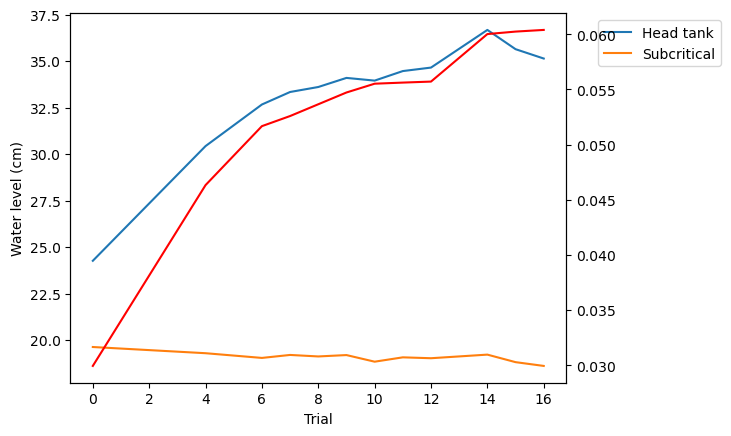

In [116]:
fig, ax1 = plt.subplots()

ax1.plot(sensor_data['Head Tank Height (cm)'])
ax1.plot(sensor_data['Subcritical Height (cm)'])
plt.legend(['Head tank', 'Subcritical', 'Supercritical'], bbox_to_anchor=(1.05, 1))
plt.xlabel('Trial')
plt.ylabel('Water level (cm)')
#plt.plot(sensor_data['Supercritical Height (cm)'])

ax2 = ax1.twinx()
ax2.plot(sensor_data['Discharge (m^3/s)'], color='red')

## Ocean and river combos

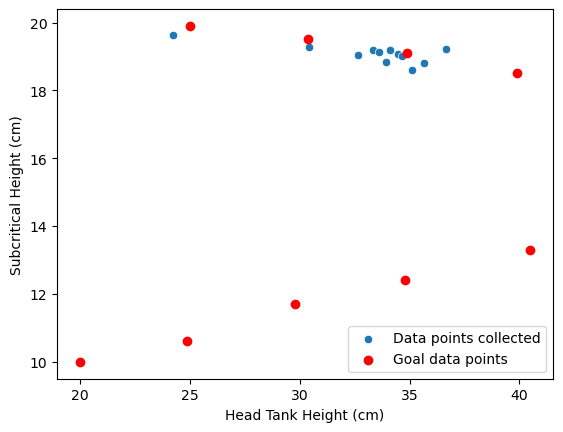

In [117]:
sns.scatterplot(x='Head Tank Height (cm)', y='Subcritical Height (cm)', data=sensor_data, label='Data points collected')

goal_data_head = np.array([20, 24.9, 29.8, 34.8, 40.5, 39.9, 34.9, 30.4, 25])
goal_data_river = np.array([9.99, 10.6, 11.7, 12.4, 13.3, 18.5, 19.1, 19.5, 19.9])

plt.scatter(goal_data_head, goal_data_river, color='red', label='Goal data points')

plt.legend()

## Calculate Re, Fr, head loss, etc

In [118]:
def calc_head_loss(sub, super):
    return ((sub - super)**3)/(4*sub*super)


def calc_Re(u, L):
    # L is in cm
    L = L/100
    return (u*L)/8.93e-7

sensor_data['Head loss (cm)'] = calc_head_loss(sensor_data['Subcritical Height (cm)'], sensor_data['Supercritical Height (cm)'])
sensor_data['Re subcritical'] = calc_Re(sensor_data['Venturi velocity (m/s)'], sensor_data['Subcritical Height (cm)'])
sensor_data['Re supercritical'] = calc_Re(sensor_data['Discharge (m^3/s)']/((sensor_data['Supercritical Height (cm)']/100)*0.5), sensor_data['Supercritical Height (cm)'])

display(sensor_data)

,V_ai0,V_ai1,V_ai2,Vernier,Filenames,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Average PV (in H2O),Average velocity (m/s),Discharge (m^3/s),Venturi velocity (m/s),Head diff (cm),Head loss (cm),Re subcritical,Re supercritical
0,-3.357145,-0.154343,-8.786971,0.505,2025-11-24_11-08-18_sensor_data.csv,17.675825,19.624984,24.260490,5.730495,0.269195,0.029924,0.304960,4.635507,0.005337,67019.352943,67019.352943
4,-3.503855,-0.117778,-5.733980,0.505,2025-11-24_16-59-13_sensor_data.csv,17.759917,19.291523,30.427221,13.578475,0.437117,0.046323,0.480239,11.135698,0.002622,103746.194733,103746.194733
6,-3.615268,-0.095309,-4.626886,0.505,2025-11-24_17-08-12_sensor_data.csv,17.811592,19.038291,32.663438,16.866686,0.490445,0.051669,0.542788,13.625147,0.001361,115719.628673,115719.628673
7,-3.544834,-0.095334,-4.294079,0.505,2025-11-24_17-10-25_sensor_data.csv,17.811535,19.198383,33.335673,17.466792,0.496938,0.052586,0.547816,14.137290,0.001950,117773.531332,117773.531332
8,-3.580417,-0.095351,-4.161254,0.505,2025-11-24_17-12-13_sensor_data.csv,17.811495,19.117503,33.603966,18.178795,0.506811,0.053654,0.561304,14.486463,0.001635,120164.880542,120164.880542
9,-3.547795,-0.095361,-3.919169,0.505,2025-11-24_17-14-19_sensor_data.csv,17.811472,19.191652,34.092952,18.904731,0.513794,0.054721,0.570256,14.901299,0.001923,122554.997055,122554.997055
10,-3.704402,-0.095346,-3.991237,0.505,2025-11-24_17-16-14_sensor_data.csv,17.811507,18.835698,33.947383,19.456557,0.529080,0.055518,0.589501,15.111686,0.000801,124341.128518,124341.128518
11,-3.601577,-0.095373,-3.737209,0.505,2025-11-24_17-18-15_sensor_data.csv,17.811446,19.069410,34.460493,19.526659,0.527341,0.055619,0.583330,15.391083,0.001465,124566.198926,124566.198926
12,-3.622394,-0.095357,-3.644243,0.505,2025-11-24_17-21-26_sensor_data.csv,17.811482,19.022094,34.648275,19.590660,0.530733,0.055710,0.585744,15.626180,0.001309,124771.329667,124771.329667
14,-3.537220,-0.095348,-2.641987,0.505,2025-11-24_17-32-35_sensor_data.csv,17.811503,19.215687,36.672730,22.720629,0.561354,0.060019,0.624690,17.457043,0.002022,134421.671229,134421.671229


Plot Re

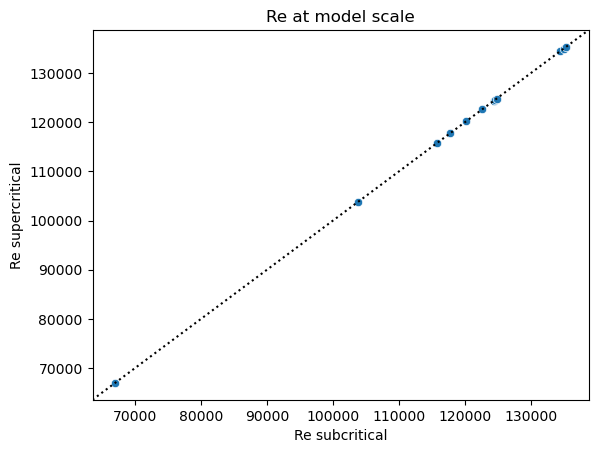

In [119]:
sns.scatterplot(x='Re subcritical', y='Re supercritical', data=sensor_data)
plt.title('Re at model scale')
plt.axline(xy1=(70000,70000), slope=1, color='black', linestyle=':')

## Map discharge data to time on the hydrograph

In [120]:
goal_data = pd.read_csv('goal_data.csv')
goal_data_collected = goal_data.drop([0,1,2,3,4,5])
goal_data_collected['Ocean pts'] = goal_data_collected['Ocean pts']*100
goal_data_collected['River pts'] = goal_data_collected['River pts']*100
display(goal_data_collected)

,Datetime,Ocean pts,River pts,Side
6,2022-07-15 02:40:00,34.854057,19.135086,after
7,2022-07-15 03:05:00,30.412686,19.526971,after
8,2022-07-15 03:35:00,24.969829,19.875314,after


In [121]:
# Find closest sensor_data rows for each goal point using Euclidean distance
# Matches 'Head Tank Height (cm)' -> 'Ocean pts' and 'Subcritical Height (cm)' -> 'River pts'
# Result: add matched index and distance to goal_data_collected (a copy) and display matches
import numpy as np
# Ensure required dataframes exist: goal_data_collected and sensor_data
try:
    gd = goal_data_collected.reset_index(drop=True).copy()
    sd = sensor_data.reset_index(drop=True).copy()
except NameError as e:
    raise NameError('Make sure `goal_data_collected` and `sensor_data` are defined and in scope before running this cell.') from e

# Columns to use
gd_cols = ['Ocean pts','River pts']
sd_cols = ['Head Tank Height (cm)','Subcritical Height (cm)']

# Drop rows with NaNs in the relevant columns to avoid errors
gd_clean = gd.dropna(subset=gd_cols).reset_index(drop=True)
sd_clean = sd.dropna(subset=sd_cols).reset_index(drop=True)

# Convert to numpy arrays for fast distance calculation
sd_arr = sd_clean[sd_cols].to_numpy(dtype=float)  # shape (n_sensors, 2)
results = []
for i, grow in gd_clean.iterrows():
    goal_point = np.array([grow['Ocean pts'], grow['River pts']], dtype=float)
    # compute Euclidean distance to every sensor row (Head, Subcritical)
    # note: sensor order is [Head, Subcritical] which corresponds to [Ocean pts, River pts] per your mapping
    diffs = sd_arr - goal_point  # broadcasting
    dists = np.linalg.norm(diffs, axis=1)
    min_idx_rel = np.argmin(dists)
    min_dist = float(dists[min_idx_rel])
    # map back to original sensor_data index (sd_clean has reset_index)
    # if sd was a reset_index copy of sensor_data then min_idx_rel corresponds to that index in sd_clean
    matched_sensor_index = sd_clean.index[min_idx_rel]
    # Retrieve matched sensor values
    matched_head = sd_clean.iloc[min_idx_rel][sd_cols[0]]
    matched_sub = sd_clean.iloc[min_idx_rel][sd_cols[1]]
    results.append({
        'goal_index': i,
        'goal_Ocean_pts': grow['Ocean pts'],
        'goal_River_pts': grow['River pts'],
        'matched_sensor_index': int(matched_sensor_index),
        'matched_Head_Tank_cm': matched_head,
        'matched_Subcritical_cm': matched_sub,
        'distance': min_dist
    })

matches_df = pd.DataFrame(results)
# Join matches back to a copy of goal_data_collected (aligned by reset index)
gd_matched = pd.concat([gd_clean.reset_index(drop=True), matches_df.set_index('goal_index')], axis=1)

# If you want to add a column to the original goal_data_collected with the matched sensor index and distance:
goal_data_collected = goal_data_collected.reset_index(drop=True)
goal_data_collected[['matched_sensor_index','matched_distance']] = gd_matched[['matched_sensor_index','distance']]

# And if you'd like to add the matched sensor values back to the goal table too:
goal_data_collected['matched_Head_Tank_cm'] = gd_matched['matched_Head_Tank_cm']
goal_data_collected['matched_Subcritical_cm'] = gd_matched['matched_Subcritical_cm']

display(goal_data_collected)

,Datetime,Ocean pts,River pts,Side,matched_sensor_index,matched_distance,matched_Head_Tank_cm,matched_Subcritical_cm
0,2022-07-15 02:40:00,34.854057,19.135086,after,8,0.234763,34.648275,19.022094
1,2022-07-15 03:05:00,30.412686,19.526971,after,1,0.235897,30.427221,19.291523
2,2022-07-15 03:35:00,24.969829,19.875314,after,0,0.752214,24.260490,19.624984


In [128]:
discharge_vals = sensor_data['Discharge (m^3/s)'][[12,4,0]].values

goal_data_collected['Datetime'] = pd.to_datetime(goal_data_collected['Datetime'])
start_time = goal_data_collected['Datetime'][0]
times = goal_data_collected['Datetime'] - start_time
times = times/np.timedelta64(1, 's')


def trap(times, vals):
    sum_val = 0

    for i in range(1, len(times)):
        sum_val += 0.5 * (vals[i-1] + vals[i]) * (times[i] - times[i-1])

    return sum_val

cumulative_discharge = trap(times, discharge_vals)

print(f'Cumulative discharge: {(cumulative_discharge*7**2.5)*0.24:0.3f} m^3')

Cumulative discharge: 4516.107 m^3


Text(0, 0.5, 'instantaneous discharge (m^3/s)')

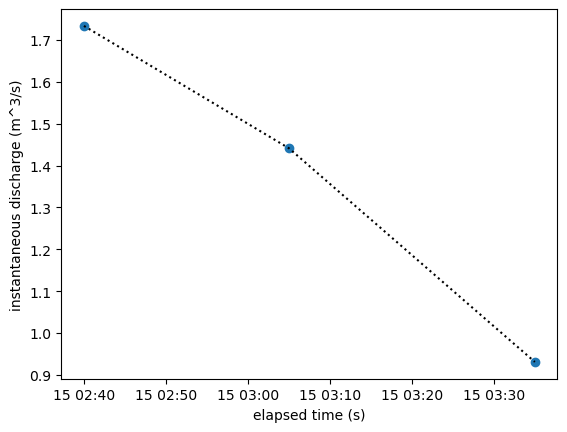

In [125]:
#plt.figure(figsize=(5,7))

plt.scatter(goal_data_collected['Datetime'], (discharge_vals*7**(2.5))*0.24)
plt.plot(goal_data_collected['Datetime'], (discharge_vals*7**(2.5))*0.24, 'k:')
plt.xlabel('elapsed time (s)')
plt.ylabel('instantaneous discharge (m^3/s)')